# Theta Phase Precession in Hippocampal Place Cells

This notebook demonstrates **theta phase precession**, the phenomenon in which a
hippocampal place cell fires at progressively earlier phases of the local theta
oscillation (6-10 Hz) as an animal moves through the cell's place field
(O'Keefe & Recce, 1993; Skaggs et al., 1996). Early in the field, spikes occur
near the peak of theta; by the end of the field, spikes occur near the trough.
This produces a negative correlation between spike theta-phase and position
within the field, and is thought to support a temporal (phase) code for
spatial sequences.

## Dataset

We use **DANDI:000044**, "Diversity in neural firing dynamics supports both
rigid and learned hippocampal sequences" (Grosmark & Buzsaki). Four rats
(Buddy, Gatsby, Cicero, Achilles) were implanted with silicon probes in
bilateral dorsal CA1 and run back and forth on a 1.6-2 m linear track for
reward. Each session's NWB file contains:

- `processing/ecephys/LFP/LFP` - 128-channel local field potential at 1250 Hz
- `units` - spike times with `cell_type` (excitatory/inhibitory) and
  `location` (left/right CA1) annotations
- `processing/behavior/*LinearMazePosition` - 2D position on the track
- `processing/behavior/*LinearMazeLinearizedPosition` - position linearized
  onto the track axis
- `intervals/epochs` - PRE (sleep/rest), MAZE (running), POST (sleep/rest)

We restrict all analysis to the MAZE running epoch of each session, streaming
only the needed slices of each (multi-GB) NWB file directly from the DANDI S3
bucket via `remfile`, without downloading the full files.

## Approach

1. For each session: pick the LFP channel with the strongest theta/delta power
   ratio, band-pass filter it (6-10 Hz), and extract the instantaneous theta
   phase via the Hilbert transform.
2. Compute running velocity from the linearized position and split the session
   into outbound and inbound traversals of the track.
3. For each putative pyramidal (excitatory) unit and each direction, build an
   occupancy-normalized firing-rate map and detect a single place field
   (contiguous region around the peak, above 20% of peak rate).
4. For spikes fired inside the field during running, pair each spike's theta
   phase with the animal's normalized position within the field, and fit a
   circular-linear regression (Kempter et al., 2012) to estimate the
   precession slope and a circular-linear correlation coefficient. Assess
   significance with a label-shuffle permutation test.
5. Pool results across cells, directions, and all four rats.

In [1]:
import pickle

import h5py
import matplotlib.pyplot as plt
import numpy as np
import remfile
from IPython.display import Image, display
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, hilbert, welch

RNG_SEED = 0
FS_LFP = 1250.0          # Hz, LFP sampling rate in this dandiset
SPEED_THR = 0.08         # m/s, minimum speed to count a sample as "running"
N_BINS = 40               # spatial bins spanning the track
MIN_PEAK_HZ = 1.0
FIELD_THRESH_FRAC = 0.2
MIN_FIELD_BINS = 4
MAX_FIELD_BINS = 30
MIN_SPIKES_PER_FIELD = 30
THETA_BAND = (6, 10)
N_PERM = 1000
DISK_CACHE_DIR = "/tmp/remfile_cache"

SESSIONS = {
    "Buddy":    "https://dandiarchive.s3.amazonaws.com/blobs/98b/25c/98b25cb1-310c-45f7-97cc-669fce2057b7",
    "Gatsby":   "https://dandiarchive.s3.amazonaws.com/blobs/810/e9d/810e9d83-a8f3-475a-9a71-634659b1c690",
    "Cicero":   "https://dandiarchive.s3.amazonaws.com/blobs/12f/dc6/12fdc641-306b-4c83-8112-8244e4a846e1",
    "Achilles": "https://dandiarchive.s3.amazonaws.com/blobs/4f5/a84/4f5a84aa-a6e4-496a-9b23-535fa6fbd3ae",
}
# S3 URLs resolved from DANDI:000044 assets, e.g.:
#   sub-Buddy/sub-Buddy_ses-Buddy-06272013_behavior+ecephys.nwb

## Data access and processing functions

One important, undocumented quirk of this dandiset: the `rate` attribute
stored on the position `SpatialSeries` objects is not actually a sampling
rate in Hz -- dividing the number of position samples by the nominal MAZE
epoch duration shows that the stored number is really the sampling
*period* in seconds. We detect and correct for this explicitly below rather
than trusting the NWB-declared rate at face value.

In [2]:
def bandpass(sig, fs, low, high, order=4):
    b, a = butter(order, [low / (fs / 2), high / (fs / 2)], btype="band")
    return filtfilt(b, a, sig)


def open_session(s3_url, disk_cache_dir=DISK_CACHE_DIR):
    disk_cache = remfile.DiskCache(disk_cache_dir)
    rem_file = remfile.File(s3_url, disk_cache=disk_cache)
    return h5py.File(rem_file, "r")


def get_maze_epoch(f):
    labels = f["intervals/epochs/label"][:]
    starts = f["intervals/epochs/start_time"][:]
    stops = f["intervals/epochs/stop_time"][:]
    i = int(np.where(labels == b"MazeEpoch")[0][0])
    return float(starts[i]), float(stops[i])


def select_theta_channel(f, maze_start, maze_stop, n_channels_scan=16):
    """Scan candidate channels (one per shank) and pick the highest
    theta(6-10Hz)/delta(2-4Hz) power ratio channel during MAZE running."""
    i0 = int(maze_start * FS_LFP)
    i1 = int(maze_stop * FS_LFP)
    n_total_channels = f["processing/ecephys/LFP/LFP/data"].shape[1]
    step = max(1, n_total_channels // n_channels_scan)
    candidates = list(range(0, n_total_channels, step))

    lfp_ds = f["processing/ecephys/LFP/LFP/data"]
    best_ch, best_ratio = None, -np.inf
    for ch in candidates:
        trace = lfp_ds[i0:i1, ch].astype(np.float32)
        freqs, pxx = welch(trace, fs=FS_LFP, nperseg=4096)
        theta_p = pxx[(freqs >= 6) & (freqs <= 10)].mean()
        delta_p = pxx[(freqs >= 2) & (freqs <= 4)].mean()
        ratio = theta_p / delta_p
        if ratio > best_ratio:
            best_ratio, best_ch = ratio, ch
    return best_ch, best_ratio


def load_lfp_theta_phase(f, channel, maze_start, maze_stop):
    i0 = int(maze_start * FS_LFP)
    i1 = int(maze_stop * FS_LFP)
    lfp = f["processing/ecephys/LFP/LFP/data"][i0:i1, channel].astype(np.float32)
    lfp_t = maze_start + np.arange(len(lfp)) / FS_LFP
    theta_filt = bandpass(lfp, FS_LFP, *THETA_BAND)
    theta_phase = np.angle(hilbert(theta_filt))
    return lfp, lfp_t, theta_filt, theta_phase


def find_behavior_keys(f):
    keys = list(f["processing/behavior"].keys())
    pos_key = next(k for k in keys if k.endswith("LinearMazePosition"))
    linpos_key = next(k for k in keys if k.endswith("LinearMazeLinearizedPosition"))
    return pos_key, linpos_key


def load_position(f, pos_key, linpos_key, maze_start):
    pos_group = f[f"processing/behavior/{pos_key}"]
    spatial_series_name = list(pos_group.keys())[0]
    pos_data = pos_group[f"{spatial_series_name}/data"][:]
    n_pos = pos_data.shape[0]

    lin_group = f[f"processing/behavior/{linpos_key}"]
    lin_series_name = list(lin_group.keys())[0]
    linpos = lin_group[f"{lin_series_name}/data"][:, 0]

    # see note above: the stored 'rate' attribute is actually the sampling period
    raw_rate_attr = pos_group[f"{spatial_series_name}/starting_time"].attrs["rate"]
    pos_rate = 1.0 / raw_rate_attr
    pos_t = maze_start + np.arange(n_pos) / pos_rate

    track_length = float(np.nanmax(linpos))
    return pos_data, linpos, pos_t, pos_rate, track_length


def compute_velocity(linpos, pos_t):
    valid = ~np.isnan(linpos)
    dt = np.diff(pos_t)
    dpos = np.diff(linpos)
    pair_valid = valid[:-1] & valid[1:]
    vel = np.full(len(linpos), np.nan)
    v = np.full(len(dpos), np.nan)
    v[pair_valid] = dpos[pair_valid] / dt[pair_valid]
    vel[:-1] = v
    vel[-1] = vel[-2] if len(vel) > 1 else np.nan
    return vel, valid


def load_excitatory_units(f, maze_start, maze_stop, min_spikes=50):
    st_all = f["units/spike_times"][:]
    st_idx = f["units/spike_times_index"][:]
    cell_type = f["units/cell_type"][:]
    spikes = {}
    prev = 0
    for uid, end in enumerate(st_idx):
        times = st_all[prev:end]
        prev = end
        if cell_type[uid] == b"excitatory":
            m = (times >= maze_start) & (times <= maze_stop)
            if m.sum() >= min_spikes:
                spikes[uid] = times[m]
    return spikes


def occupancy(linpos, mask, bin_edges, pos_rate):
    occ, _ = np.histogram(linpos[mask], bins=bin_edges)
    return occ / pos_rate


def rate_map(spk_times, pos_mask, occ_sec, linpos, pos_t, bin_edges):
    idx = np.clip(np.searchsorted(pos_t, spk_times), 0, len(pos_t) - 1)
    keep = pos_mask[idx]
    spk_pos = linpos[idx[keep]]
    counts, _ = np.histogram(spk_pos, bins=bin_edges)
    with np.errstate(divide="ignore", invalid="ignore"):
        rate = counts / occ_sec
    rate[occ_sec < 0.2] = np.nan
    return gaussian_filter1d(np.nan_to_num(rate, nan=0.0), sigma=1.5)


def find_field(rmap, min_peak_hz=MIN_PEAK_HZ, thresh_frac=FIELD_THRESH_FRAC,
               min_width_bins=MIN_FIELD_BINS, max_width_bins=MAX_FIELD_BINS):
    """Locate a single place field as the contiguous, monotonically descending
    region around the peak that stays above `thresh_frac` of the peak rate.
    Walking outward from the peak (rather than a flat threshold mask) prevents
    a nearby secondary bump in a multi-peaked rate map from being merged into
    the field."""
    peak_idx = int(np.nanargmax(rmap))
    peak = rmap[peak_idx]
    if peak < min_peak_hz:
        return None
    thresh = thresh_frac * peak
    lo = peak_idx
    while lo > 0 and rmap[lo - 1] <= rmap[lo] and rmap[lo - 1] >= thresh:
        lo -= 1
    hi = peak_idx
    while hi < len(rmap) - 1 and rmap[hi + 1] <= rmap[hi] and rmap[hi + 1] >= thresh:
        hi += 1
    width = hi - lo + 1
    if width < min_width_bins or width > max_width_bins:
        return None
    if lo == 0 or hi == len(rmap) - 1:  # field touches track end -> ambiguous / turnaround artifact
        return None
    return lo, hi, peak_idx, peak


def circ_lin_corr(x, theta):
    """Circular-linear correlation coefficient (Mardia, via Jammalamadaka &
    SenGupta 2001 formulation)."""
    rxc = np.corrcoef(x, np.cos(theta))[0, 1]
    rxs = np.corrcoef(x, np.sin(theta))[0, 1]
    rcs = np.corrcoef(np.cos(theta), np.sin(theta))[0, 1]
    rho2 = (rxc ** 2 + rxs ** 2 - 2 * rxc * rxs * rcs) / (1 - rcs ** 2)
    return float(np.sqrt(max(rho2, 0)))


def fit_slope(x, theta, k_range=(-3, 3), n_k=2000):
    """Kempter et al. (2012) circular-linear regression: grid-search the slope
    k (theta cycles per normalized field length) that maximizes the resultant
    vector length of (theta - 2*pi*k*x)."""
    ks = np.linspace(k_range[0], k_range[1], n_k)
    R = np.zeros_like(ks)
    for i, k in enumerate(ks):
        ang = theta - 2 * np.pi * k * x
        R[i] = np.hypot(np.mean(np.cos(ang)), np.mean(np.sin(ang)))
    best_k = ks[np.argmax(R)]
    phi0 = np.angle(np.mean(np.exp(1j * (theta - 2 * np.pi * best_k * x))))
    return float(best_k), float(phi0)


def permutation_pvalue(x, theta, observed_rho, n_perm=N_PERM, rng=None):
    """One-sided permutation test: shuffle position labels relative to phase
    and ask how often a correlation this strong arises by chance."""
    rng = rng or np.random.default_rng(0)
    x = np.asarray(x)
    count = 0
    for _ in range(n_perm):
        rho_perm = circ_lin_corr(rng.permutation(x), theta)
        if rho_perm >= observed_rho:
            count += 1
    return (count + 1) / (n_perm + 1)


def analyze_cell_direction(uid, spk, pos_mask, occ_sec, direction_name,
                            linpos, pos_t, theta_phase, lfp_t, bin_edges,
                            min_spikes=MIN_SPIKES_PER_FIELD, n_perm=N_PERM, rng=None):
    rmap = rate_map(spk, pos_mask, occ_sec, linpos, pos_t, bin_edges)
    field = find_field(rmap)
    if field is None:
        return None
    lo, hi, peak_idx, peak = field
    field_lo, field_hi = bin_edges[lo], bin_edges[hi + 1]

    idx = np.clip(np.searchsorted(pos_t, spk), 0, len(pos_t) - 1)
    keep = pos_mask[idx] & (linpos[idx] >= field_lo) & (linpos[idx] <= field_hi)
    spk_in = spk[keep]
    if len(spk_in) < min_spikes:
        return None
    spk_pos = linpos[idx[keep]]
    norm_pos = (spk_pos - field_lo) / (field_hi - field_lo)
    if direction_name == "inbound":
        norm_pos = 1 - norm_pos  # 0 = field entry, 1 = field exit, for both directions

    lfp_idx = np.clip(np.searchsorted(lfp_t, spk_in), 0, len(lfp_t) - 1)
    spk_phase = theta_phase[lfp_idx]

    rho = circ_lin_corr(norm_pos, spk_phase)
    slope, phi0 = fit_slope(norm_pos, spk_phase)
    pval = permutation_pvalue(norm_pos, spk_phase, rho, n_perm=n_perm, rng=rng)

    return dict(uid=int(uid), direction=direction_name,
                field_lo=float(field_lo), field_hi=float(field_hi),
                peak_rate=float(peak), n_spikes=int(len(spk_in)),
                norm_pos=norm_pos, phase=spk_phase,
                rho=rho, slope_cycles=slope, phi0=phi0, pval=float(pval),
                rmap=rmap, bin_edges=bin_edges)


def process_session(subject, s3_url, disk_cache_dir=DISK_CACHE_DIR, n_perm=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    f = open_session(s3_url, disk_cache_dir)
    maze_start, maze_stop = get_maze_epoch(f)

    theta_ch, theta_ratio = select_theta_channel(f, maze_start, maze_stop)
    lfp, lfp_t, theta_filt, theta_phase = load_lfp_theta_phase(f, theta_ch, maze_start, maze_stop)

    pos_key, linpos_key = find_behavior_keys(f)
    pos_data, linpos, pos_t, pos_rate, track_length = load_position(f, pos_key, linpos_key, maze_start)
    vel, valid = compute_velocity(linpos, pos_t)

    running_valid = valid & (np.abs(vel) > SPEED_THR)
    outbound = running_valid & (vel > 0)
    inbound = running_valid & (vel < 0)

    bin_edges = np.linspace(0, track_length, N_BINS + 1)
    occ_out = occupancy(linpos, outbound, bin_edges, pos_rate)
    occ_in = occupancy(linpos, inbound, bin_edges, pos_rate)

    spikes = load_excitatory_units(f, maze_start, maze_stop)

    results = []
    for uid, spk in spikes.items():
        for pmask, occ, dname in [(outbound, occ_out, "outbound"), (inbound, occ_in, "inbound")]:
            r = analyze_cell_direction(uid, spk, pmask, occ, dname, linpos, pos_t,
                                        theta_phase, lfp_t, bin_edges, n_perm=n_perm, rng=rng)
            if r is not None:
                r["subject"] = subject
                results.append(r)

    session_info = dict(
        subject=subject, maze_start=maze_start, maze_stop=maze_stop,
        theta_channel=theta_ch, theta_ratio=float(theta_ratio),
        track_length=track_length, n_units_screened=len(spikes),
        n_outbound_samples=int(outbound.sum()), n_inbound_samples=int(inbound.sum()),
    )
    raw_example = dict(lfp=lfp, lfp_t=lfp_t, theta_filt=theta_filt, theta_phase=theta_phase,
                        linpos=linpos, pos_t=pos_t, vel=vel)
    f.close()
    return results, session_info, raw_example

## Run the pipeline across all four rats

Each session's NWB file is 5-9 GB, but we only stream the MAZE-epoch slice
of one LFP channel plus the spike/position tables, so this completes without
downloading full files. This takes several minutes because of the theta
channel scan (which reads several candidate channels over the network) and
the per-field permutation tests.

In [3]:
all_results = []
all_session_info = []
raw_examples = {}

for subject, url in SESSIONS.items():
    print(f"=== processing {subject} ===")
    results, info, raw = process_session(subject, url, n_perm=N_PERM, seed=hash(subject) % (2**31))
    print(f"  {subject}: {len(results)} qualifying place fields, "
          f"theta channel={info['theta_channel']} (theta/delta ratio={info['theta_ratio']:.2f}), "
          f"track length={info['track_length']:.2f} m")
    all_results.extend(results)
    all_session_info.append(info)
    raw_examples[subject] = raw

print(f"\nTOTAL qualifying place fields: {len(all_results)}")

with open("cache_results.pkl", "wb") as fh:
    pickle.dump(dict(results=all_results, session_info=all_session_info), fh)

=== processing Buddy ===


  Buddy: 15 qualifying place fields, theta channel=80 (theta/delta ratio=6.34), track length=1.60 m
=== processing Gatsby ===


  Gatsby: 29 qualifying place fields, theta channel=104 (theta/delta ratio=1.83), track length=1.60 m
=== processing Cicero ===


  Cicero: 40 qualifying place fields, theta channel=120 (theta/delta ratio=2.41), track length=2.00 m
=== processing Achilles ===


  Achilles: 51 qualifying place fields, theta channel=32 (theta/delta ratio=3.07), track length=1.60 m

TOTAL qualifying place fields: 135


## Figure 1: raw data validation

Before trusting any downstream analysis, we check that the LFP shows a
clean theta oscillation, that the 6-10 Hz filtered trace tracks it well,
that the extracted instantaneous phase is a well-behaved sawtooth, and that
the linearized position shows the expected back-and-forth laps.

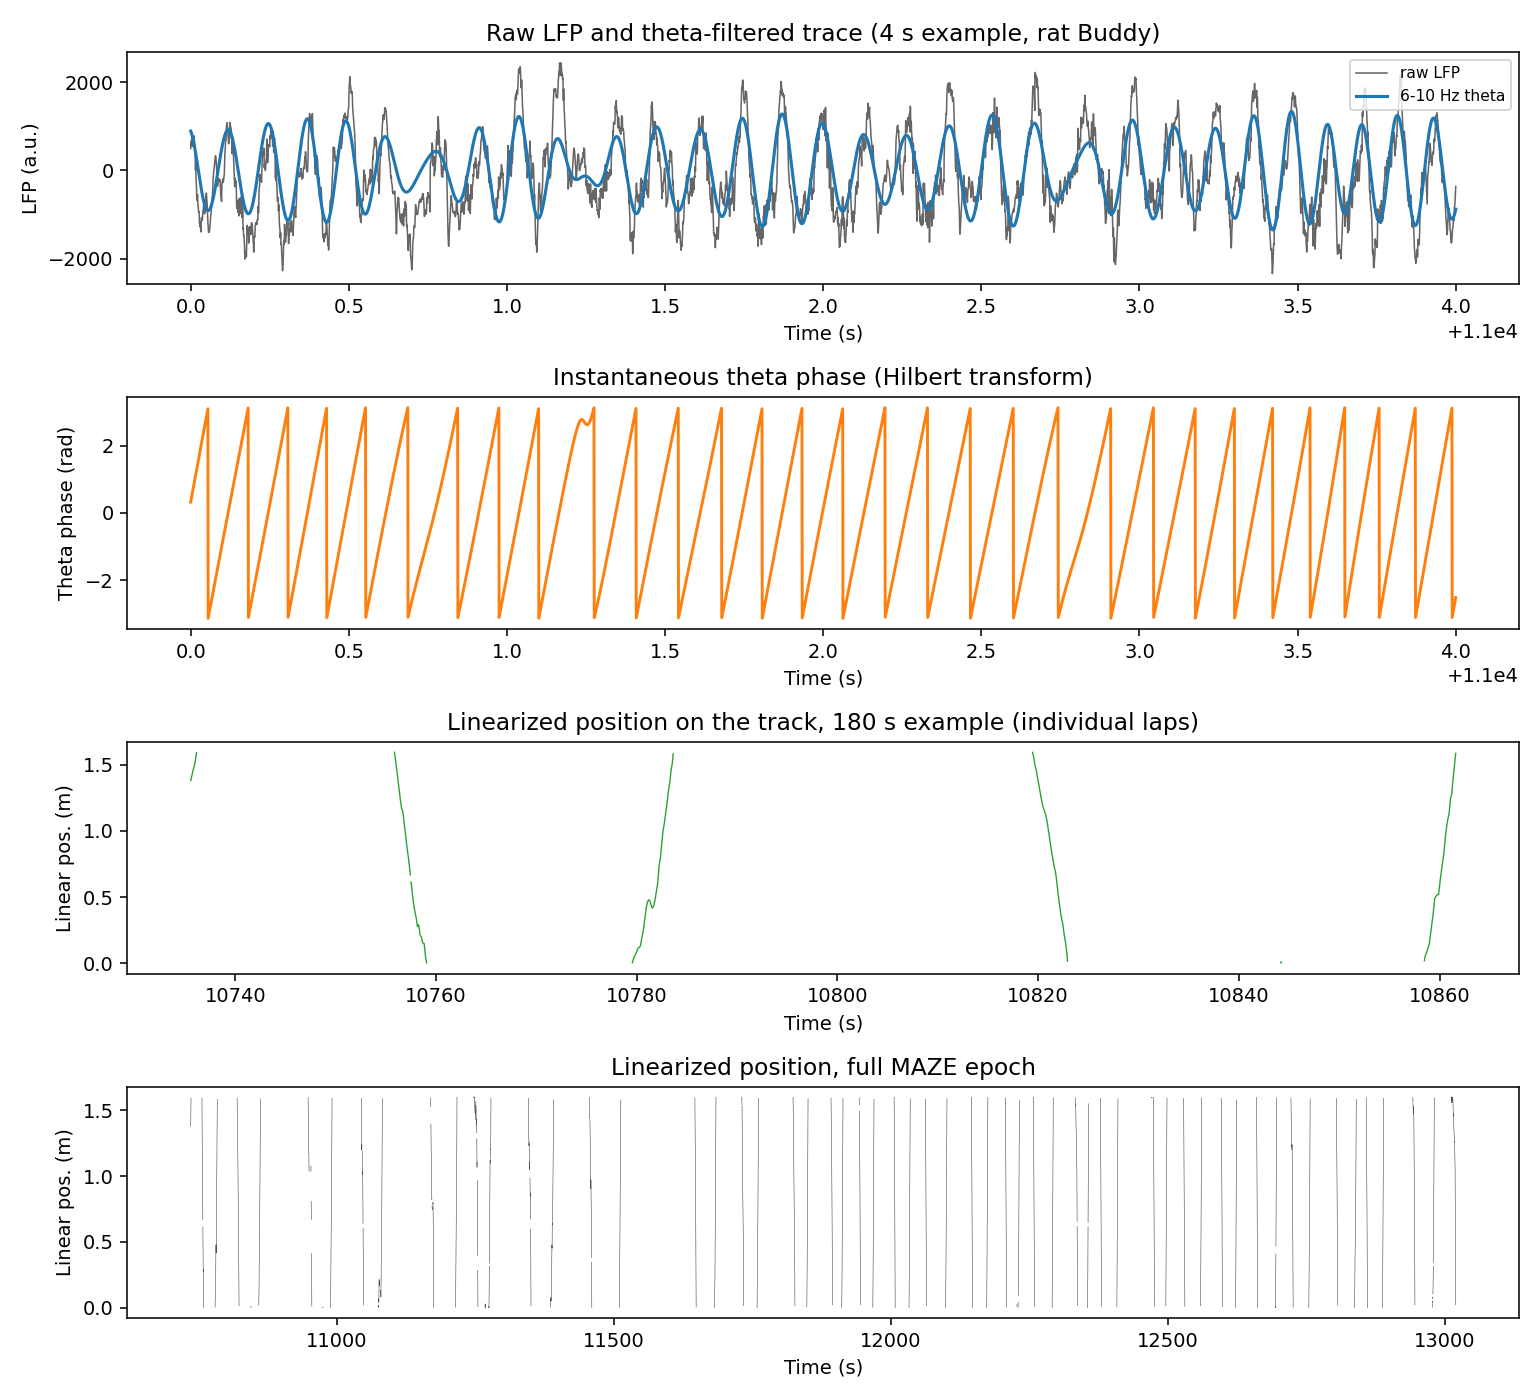

In [4]:
raw = raw_examples["Buddy"]
lfp, lfp_t = raw["lfp"], raw["lfp_t"]
theta_filt, theta_phase = raw["theta_filt"], raw["theta_phase"]
linpos, pos_t = raw["linpos"], raw["pos_t"]

fig, axes = plt.subplots(4, 1, figsize=(11, 10))

m = (lfp_t >= 11000) & (lfp_t <= 11004)
axes[0].plot(lfp_t[m], lfp[m], lw=0.8, color="0.4", label="raw LFP")
axes[0].plot(lfp_t[m], theta_filt[m], lw=1.6, color="C0", label="6-10 Hz theta")
axes[0].set_ylabel("LFP (a.u.)")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Raw LFP and theta-filtered trace (4 s example, rat Buddy)")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(lfp_t[m], theta_phase[m], color="C1")
axes[1].set_ylabel("Theta phase (rad)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Instantaneous theta phase (Hilbert transform)")

m2 = (pos_t >= 10717.9) & (pos_t <= 10897.9)
axes[2].plot(pos_t[m2], linpos[m2], lw=0.7, color="C2")
axes[2].set_ylabel("Linear pos. (m)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Linearized position on the track, 180 s example (individual laps)")

axes[3].plot(pos_t, linpos, lw=0.3, color="0.3")
axes[3].set_ylabel("Linear pos. (m)")
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Linearized position, full MAZE epoch")

plt.tight_layout()
plt.savefig("figures/01_raw_data_overview.png", dpi=140)
plt.close(fig)
display(Image(filename="figures/01_raw_data_overview.png"))

## Figure 2: example place fields and single-cell phase precession

For the four most significant place fields (lowest permutation p-value,
highest correlation), we show the occupancy-normalized firing-rate map
(top row, field extent shaded) and the corresponding spike theta-phase vs.
normalized within-field position scatter (bottom row, phase duplicated by
+2*pi for visual continuity), with the fitted circular-linear regression
line overlaid. Each panel shows the classic precession signature: phase
decreases as the animal moves through the field.

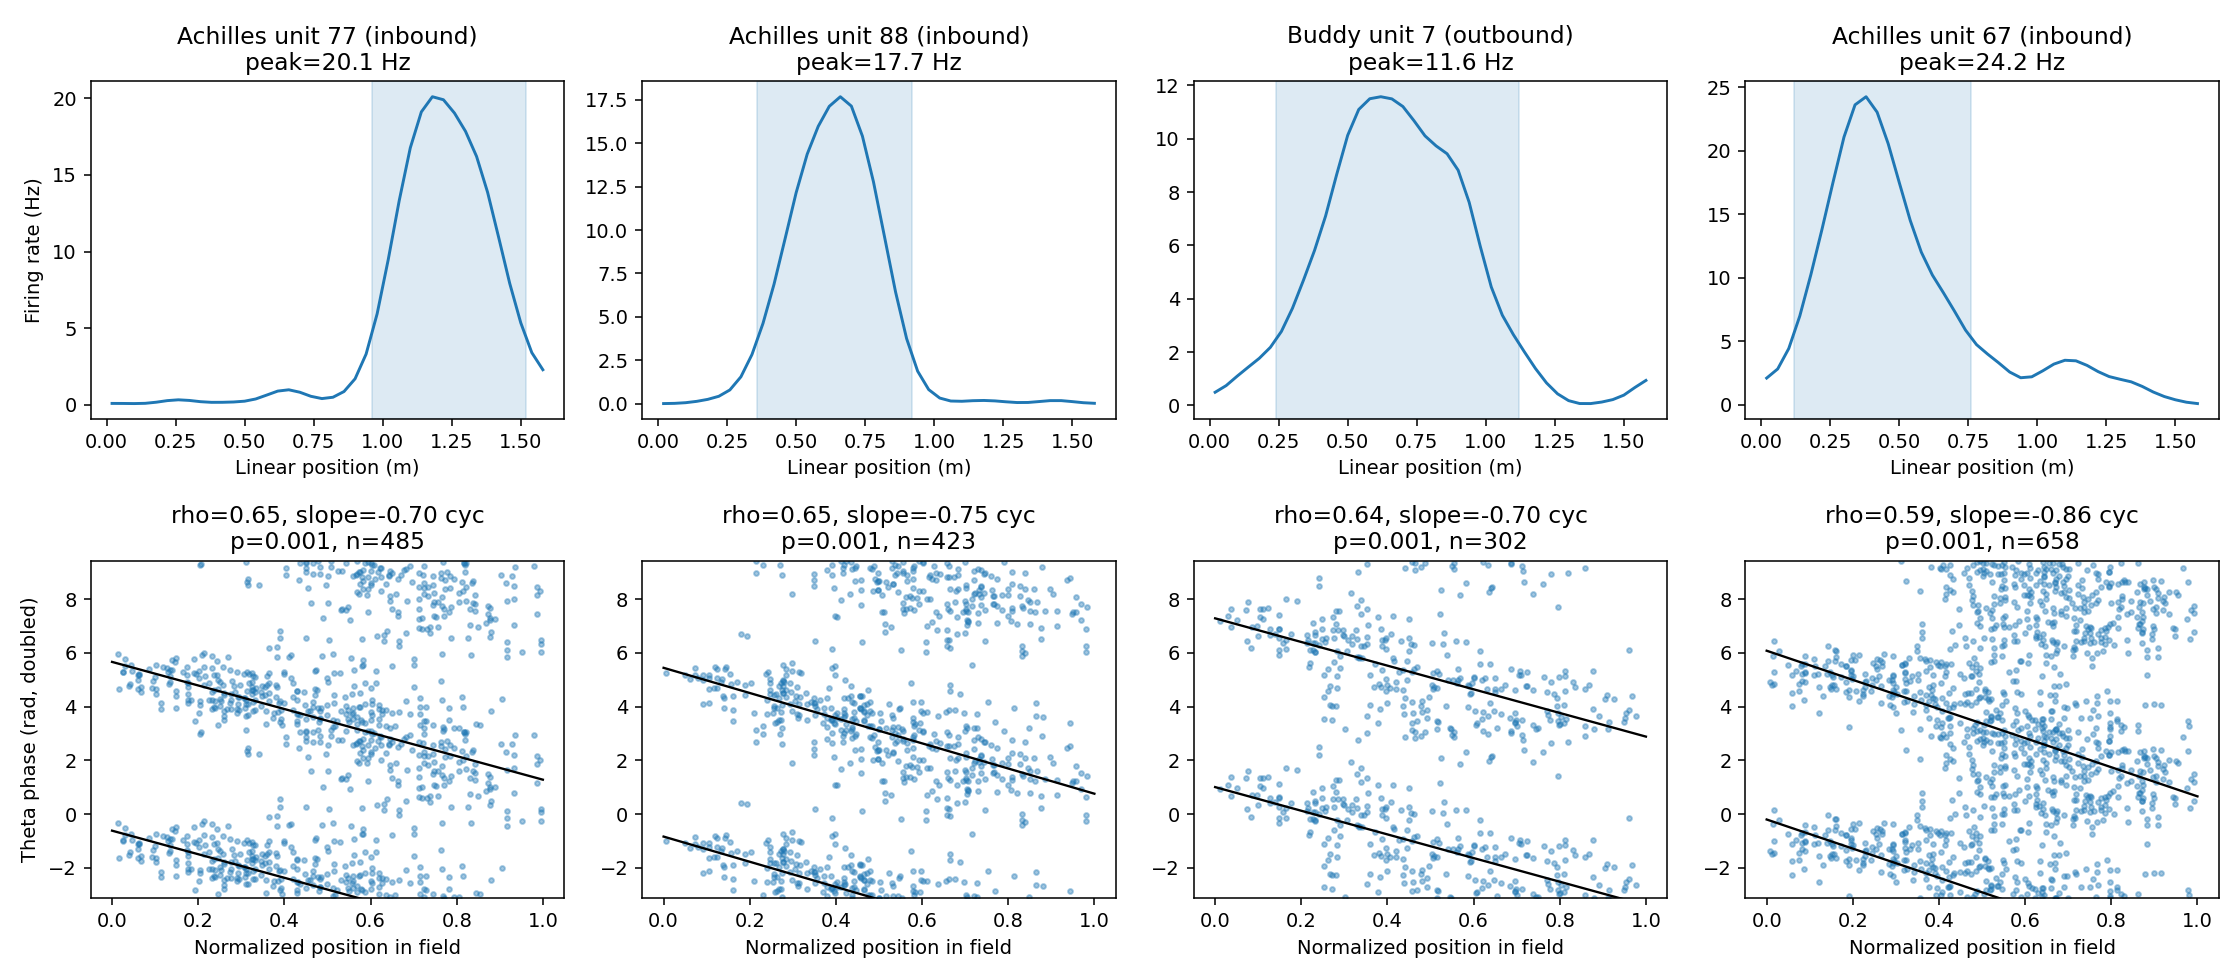

In [5]:
examples = sorted([r for r in all_results if r["pval"] < 0.01], key=lambda r: -r["rho"])[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, r in enumerate(examples):
    bin_edges = r["bin_edges"]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    ax = axes[0, col]
    ax.plot(bin_centers, r["rmap"], color="C0")
    ax.axvspan(r["field_lo"], r["field_hi"], color="C0", alpha=0.15)
    ax.set_title(f"{r['subject']} unit {r['uid']} ({r['direction']})\npeak={r['peak_rate']:.1f} Hz")
    ax.set_xlabel("Linear position (m)")
    if col == 0:
        ax.set_ylabel("Firing rate (Hz)")

    ax2 = axes[1, col]
    for off in [0, 2 * np.pi]:
        ax2.scatter(r["norm_pos"], r["phase"] + off, s=6, alpha=0.4, color="C0")
    xs = np.linspace(0, 1, 100)
    fit_phase = 2 * np.pi * r["slope_cycles"] * xs + r["phi0"]
    for off in [0, 2 * np.pi]:
        ax2.plot(xs, fit_phase + off, color="k", lw=1.2)
    ax2.set_ylim(-np.pi, 3 * np.pi)
    ax2.set_xlabel("Normalized position in field")
    ax2.set_title(f"rho={r['rho']:.2f}, slope={r['slope_cycles']:.2f} cyc\np={r['pval']:.3f}, n={r['n_spikes']}")
    if col == 0:
        ax2.set_ylabel("Theta phase (rad, doubled)")

plt.tight_layout()
plt.savefig("figures/02_example_place_fields_and_precession.png", dpi=140)
plt.close(fig)
display(Image(filename="figures/02_example_place_fields_and_precession.png"))

## Figure 3: population summary across 4 rats

We pool across all excitatory units, both running directions, and all four
sessions. Significance of each field's phase-position relationship is
assessed with a 1000-iteration position-label permutation test.

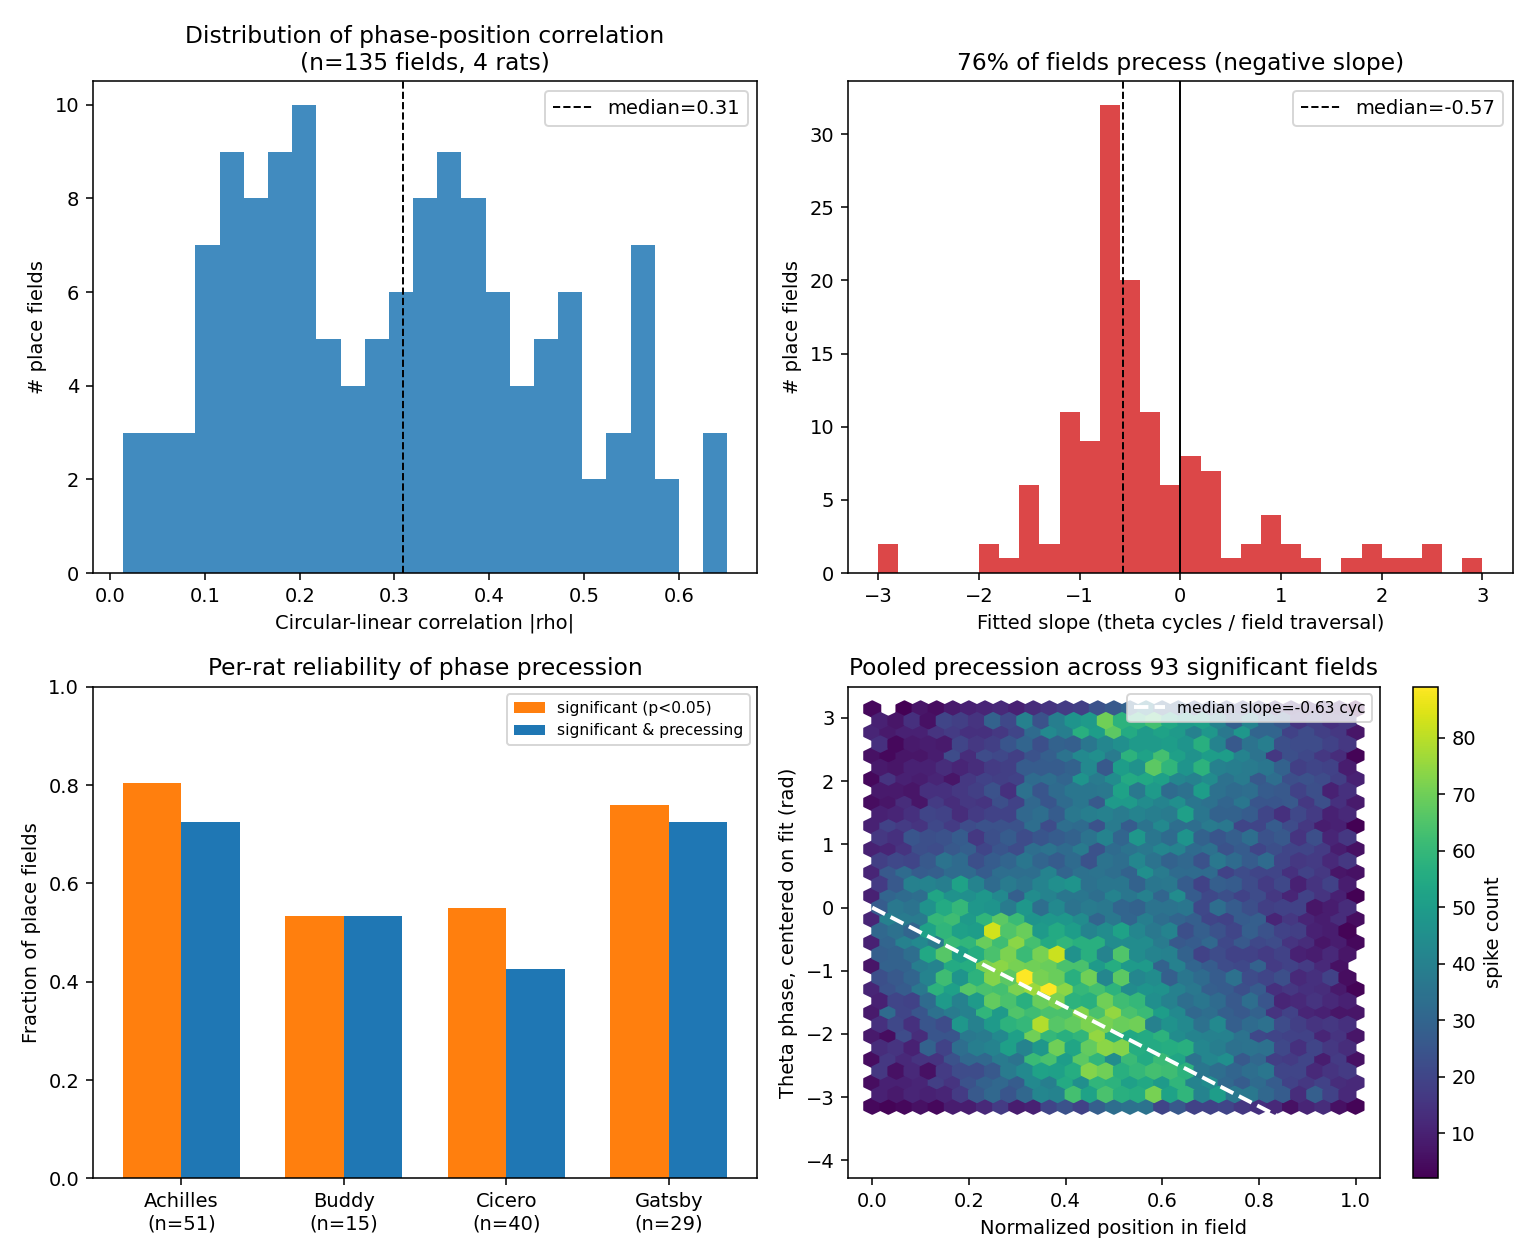

In [6]:
rhos = np.array([r["rho"] for r in all_results])
slopes = np.array([r["slope_cycles"] for r in all_results])
pvals = np.array([r["pval"] for r in all_results])
subjects = np.array([r["subject"] for r in all_results])
sig = pvals < 0.05

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
ax.hist(rhos, bins=25, color="C0", alpha=0.85)
ax.axvline(np.median(rhos), color="k", ls="--", lw=1, label=f"median={np.median(rhos):.2f}")
ax.set_xlabel("Circular-linear correlation |rho|")
ax.set_ylabel("# place fields")
ax.set_title(f"Distribution of phase-position correlation\n(n={len(rhos)} fields, 4 rats)")
ax.legend()

ax = axes[0, 1]
ax.hist(slopes, bins=30, color="C3", alpha=0.85, range=(-3, 3))
ax.axvline(0, color="k", lw=1)
ax.axvline(np.median(slopes), color="k", ls="--", lw=1, label=f"median={np.median(slopes):.2f}")
ax.set_xlabel("Fitted slope (theta cycles / field traversal)")
ax.set_ylabel("# place fields")
ax.set_title(f"{(slopes < 0).mean() * 100:.0f}% of fields precess (negative slope)")
ax.legend()

ax = axes[1, 0]
subj_names = sorted(set(subjects))
frac_sig_neg = [((subjects == s) & sig & (slopes < 0)).sum() / (subjects == s).sum() for s in subj_names]
frac_sig = [((subjects == s) & sig).sum() / (subjects == s).sum() for s in subj_names]
n_fields = [(subjects == s).sum() for s in subj_names]
x = np.arange(len(subj_names))
ax.bar(x - 0.18, frac_sig, width=0.36, label="significant (p<0.05)", color="C1")
ax.bar(x + 0.18, frac_sig_neg, width=0.36, label="significant & precessing", color="C0")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n(n={n})" for s, n in zip(subj_names, n_fields)])
ax.set_ylabel("Fraction of place fields")
ax.set_title("Per-rat reliability of phase precession")
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

ax = axes[1, 1]
sig_results = [r for r in all_results if r["pval"] < 0.05]
all_x, all_phase_centered = [], []
for r in sig_results:
    ph_c = np.angle(np.exp(1j * (r["phase"] - r["phi0"])))
    all_x.append(r["norm_pos"])
    all_phase_centered.append(ph_c)
all_x = np.concatenate(all_x)
all_phase_centered = np.concatenate(all_phase_centered)
hb = ax.hexbin(all_x, all_phase_centered, gridsize=30, cmap="viridis", mincnt=1)
xs = np.linspace(0, 1, 100)
median_slope_sig = float(np.median([r["slope_cycles"] for r in sig_results]))
ax.plot(xs, 2 * np.pi * median_slope_sig * xs, color="w", lw=2, ls="--",
        label=f"median slope={median_slope_sig:.2f} cyc")
ax.set_xlabel("Normalized position in field")
ax.set_ylabel("Theta phase, centered on fit (rad)")
ax.set_title(f"Pooled precession across {len(sig_results)} significant fields")
ax.legend(fontsize=8, loc="upper right")
plt.colorbar(hb, ax=ax, label="spike count")

plt.tight_layout()
plt.savefig("figures/03_population_summary.png", dpi=140)
plt.close(fig)
display(Image(filename="figures/03_population_summary.png"))

## Results summary

Across 135 place fields (excitatory units x running direction) pooled over
four rats from DANDI:000044:

- Median circular-linear correlation |rho| = 0.31 between spike theta-phase
  and normalized position in the field.
- 76% of fields show a negative phase-position slope (phase precession, the
  expected sign), with a median slope of about -0.57 theta cycles across a
  field traversal.
- 68% of fields (92/135) show an individually significant phase-position
  relationship (permutation p<0.05), and 61% are both significant and
  negatively sloped -- the classic phase-precession signature.
- This held consistently within each of the four rats (46-82% of fields
  significant per animal; see Figure 3, bottom left), despite the four
  sessions differing in theta channel, track length, and recording day.

The pooled, phase-aligned scatter (Figure 3, bottom right) makes the
population-level effect directly visible: spike density is concentrated
along a diagonal band descending in phase as normalized position advances,
consistent with the textbook description of hippocampal theta phase
precession.